In [1]:
import torch
import torch.nn as nn
from PIL import Image
import os

In [ ]:
from utils.dataset import CelebFaceDataset
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
IMAGE_DIR = os.path.join("..","VAE_from_scratch", "data", "celeba","img_align_celeba","img_align_celeba")
size=100000
train_ds = CelebFaceDataset(IMAGE_DIR,size=size)

In [3]:
from torch.utils.data import DataLoader
# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
BATCH_SIZE = 64  
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)

In [5]:
from models.vae import VariationalAutoencoders as VAE
import torch.nn.functional as F

model     = VAE(latent_dim=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
epochs    = 10
history   = {'train_loss': []}

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, idx in train_loader:
        images = images.to(device)

        optimizer.zero_grad()
        x_hat, mu, logvar = model(images)

        recon_loss = F.mse_loss(x_hat, images, reduction='sum')
        kl_loss    = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss       = recon_loss + kl_loss

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_ds)
    history['train_loss'].append(avg_loss)
    print(f"Epoch [{epoch+1:03d}/{epochs}] Loss: {avg_loss:.4f}")
    
    if avg_loss == min(history['train_loss']):
        torch.save({
            'epoch'               : epoch + 1,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss'                : avg_loss,
            'history'             : history
        }, 'vae_celeba_best.pth')
        print(f"  → saved best model (loss: {avg_loss:.4f})")

Epoch [001/10] Loss: 789.3383
  → saved best model (loss: 789.3383)
Epoch [002/10] Loss: 564.8627
  → saved best model (loss: 564.8627)
Epoch [003/10] Loss: 529.3921
  → saved best model (loss: 529.3921)
Epoch [004/10] Loss: 508.4053
  → saved best model (loss: 508.4053)
Epoch [005/10] Loss: 494.7133
  → saved best model (loss: 494.7133)
Epoch [006/10] Loss: 483.4038
  → saved best model (loss: 483.4038)
Epoch [007/10] Loss: 475.6084
  → saved best model (loss: 475.6084)
Epoch [008/10] Loss: 469.6617
  → saved best model (loss: 469.6617)
Epoch [009/10] Loss: 464.4722
  → saved best model (loss: 464.4722)
Epoch [010/10] Loss: 460.5619
  → saved best model (loss: 460.5619)


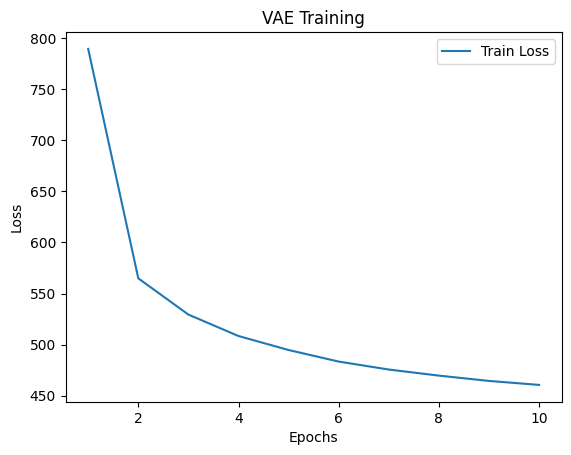

In [6]:
import matplotlib.pyplot as plt

epoch_range = range(1, len(history['train_loss']) + 1)
plt.plot(epoch_range, history['train_loss'], label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('VAE Training')
plt.legend()
plt.show()

In [8]:
# Generate and save reconstructions
import torchvision.utils as vutils
import os
import torch
from models.vae import VariationalAutoencoders as VAE

# Setup device (in case not defined)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the trained model
model = VAE(latent_dim=128).to(device)
checkpoint = torch.load('vae_celeba_best.pth')
model.load_state_dict(checkpoint['model_state_dict'])

# Ensure the output directory exists
os.makedirs('outputs/reconstructions', exist_ok=True)

model.eval()

with torch.no_grad():
    # Get a batch of images (need to recreate loader if not in memory)
    from utils.dataset import CelebFaceDataset
    from torch.utils.data import DataLoader
    
    IMAGE_DIR = os.path.join("data", "celeba","img_align_celeba","img_align_celeba")
    train_ds = CelebFaceDataset(IMAGE_DIR, size=1000)  # Smaller size for quick loading
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=0)  # No shuffle for consistency
    
    images, _ = next(iter(train_loader))
    images = images.to(device)
    
    # Generate reconstructions
    x_hat, _, _ = model(images)
    
    # Denormalize images (since they were normalized with mean=0.5, std=0.5)
    images = images * 0.5 + 0.5
    x_hat = x_hat * 0.5 + 0.5
    
    # Clamp to [0, 1]
    images = torch.clamp(images, 0, 1)
    x_hat = torch.clamp(x_hat, 0, 1)
    
    # Save individual reconstructions
    num_images = min(10, images.size(0))  # Save up to 10 images
    for i in range(num_images):
        # Save original
        vutils.save_image(images[i], f'outputs/reconstructions/original_{i}.png')
        # Save reconstruction
        vutils.save_image(x_hat[i], f'outputs/reconstructions/reconstructed_{i}.png')
    
    print(f"Saved {num_images} original and reconstructed image pairs to outputs/reconstructions/")

Saved 10 original and reconstructed image pairs to outputs/reconstructions/
